📊 Performance Comparison:

IDW:
  MAE  = 48.237
  RMSE = 93.763
  R²   = 0.821

Spherical:
  MAE  = 202.091
  RMSE = 221.494
  R²   = -0.000

🔁 Leave-One-Out CV (IDW):
  MAE  = 48.237
  RMSE = 93.763
  R²   = 0.821

🔁 Leave-One-Out CV (Spherical):
  MAE  = 202.091
  RMSE = 221.494
  R²   = -0.000


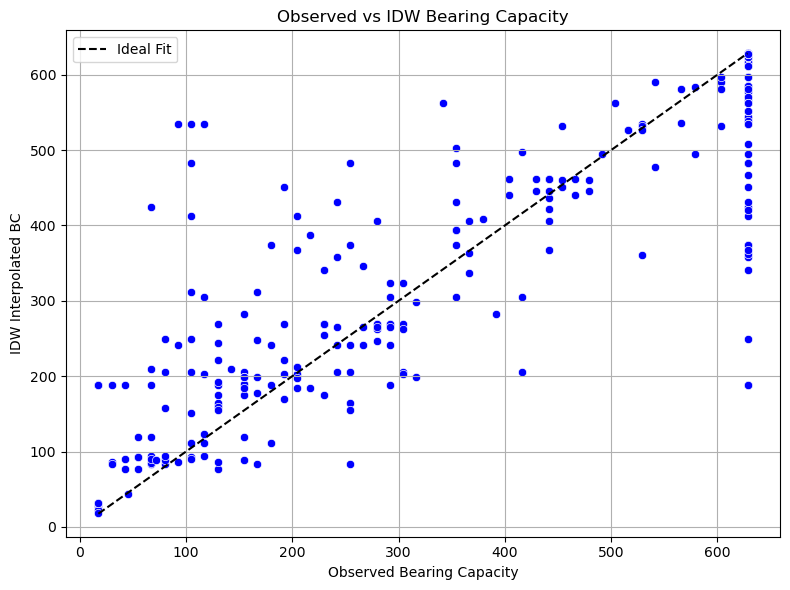

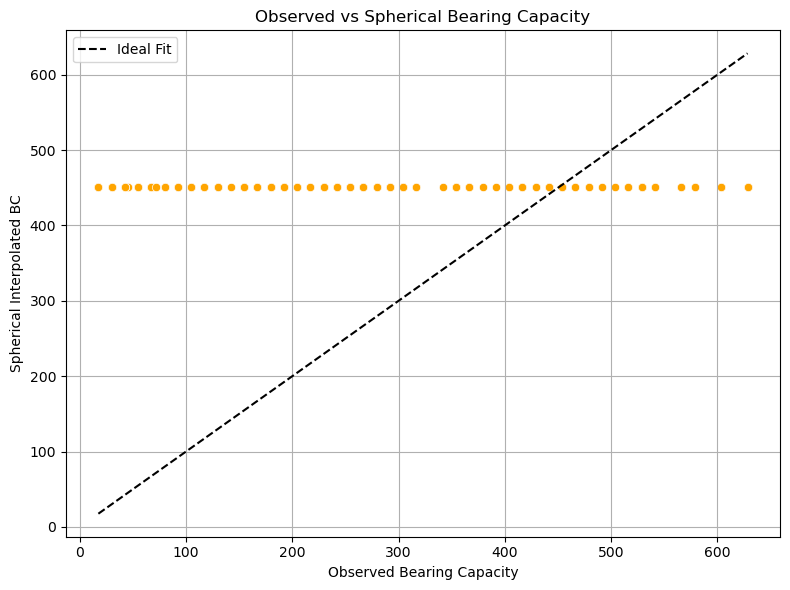

<Figure size 1000x600 with 0 Axes>

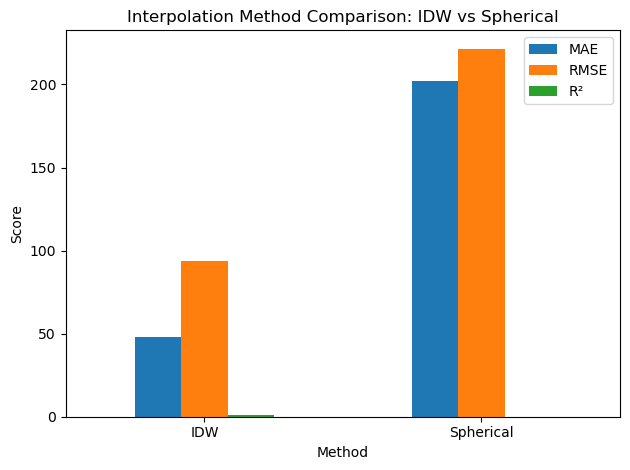

C:\Users\Dell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Dell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


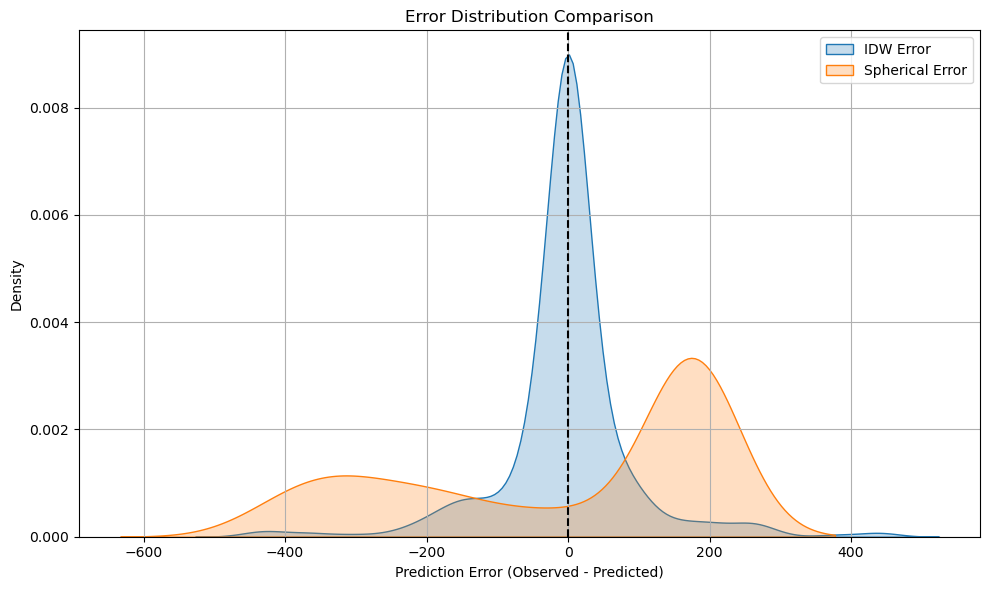

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import LeaveOneOut
import matplotlib.pyplot as plt
import seaborn as sns

observed = pd.read_csv("observed.csv")  # Sparse ground truth points
idw = pd.read_csv("idw.csv")            # IDW interpolated data
spherical = pd.read_csv("Sperical.csv")  # Spherical interpolated data

def get_nearest_bc(observed_df, interp_df):
    nbrs = NearestNeighbors(n_neighbors=1).fit(interp_df[['x', 'y']])
    distances, indices = nbrs.kneighbors(observed_df[['x', 'y']])
    nearest_bc = interp_df.iloc[indices.flatten()]['bc'].values
    return nearest_bc

observed['bc_idw'] = get_nearest_bc(observed, idw)
observed['bc_spherical'] = get_nearest_bc(observed, spherical)

def evaluate(true, pred):
    mae = mean_absolute_error(true, pred)
    rmse = np.sqrt(mean_squared_error(true, pred))
    r2 = r2_score(true, pred)
    return mae, rmse, r2

mae_idw, rmse_idw, r2_idw = evaluate(observed['bc'], observed['bc_idw'])
mae_sph, rmse_sph, r2_sph = evaluate(observed['bc'], observed['bc_spherical'])

print("📊 Performance Comparison:")
print("\nIDW:")
print(f"  MAE  = {mae_idw:.3f}")
print(f"  RMSE = {rmse_idw:.3f}")
print(f"  R²   = {r2_idw:.3f}")

print("\nSpherical:")
print(f"  MAE  = {mae_sph:.3f}")
print(f"  RMSE = {rmse_sph:.3f}")
print(f"  R²   = {r2_sph:.3f}")

#Leave-One-Out Cross Validation (LOO-CV)
def loo_cross_validate(obs_df, interp_df, method_name="Method"):
    loo = LeaveOneOut()
    y_true, y_pred = [], []
    interp_nbrs = NearestNeighbors(n_neighbors=1).fit(interp_df[['x', 'y']])

    for train_index, test_index in loo.split(obs_df):
        test_point = obs_df.iloc[test_index[0]][['x', 'y']].to_frame().T
        true_val = obs_df.iloc[test_index[0]]['bc']

        dist, idx = interp_nbrs.kneighbors(test_point)
        predicted_val = interp_df.iloc[idx[0][0]]['bc']

        y_true.append(true_val)
        y_pred.append(predicted_val)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"\n🔁 Leave-One-Out CV ({method_name}):")
    print(f"  MAE  = {mae:.3f}")
    print(f"  RMSE = {rmse:.3f}")
    print(f"  R²   = {r2:.3f}")

loo_cross_validate(observed, idw, method_name="IDW")
loo_cross_validate(observed, spherical, method_name="Spherical")

plt.figure(figsize=(8,6))
sns.scatterplot(x=observed['bc'], y=observed['bc_idw'], color='blue')
plt.plot([observed['bc'].min(), observed['bc'].max()],
         [observed['bc'].min(), observed['bc'].max()],
         'k--', label='Ideal Fit')
plt.xlabel("Observed Bearing Capacity")
plt.ylabel("IDW Interpolated BC")
plt.title("Observed vs IDW Bearing Capacity")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('IDW_vs_Observed.png', dpi=300)
plt.show()

plt.figure(figsize=(8,6))
sns.scatterplot(x=observed['bc'], y=observed['bc_spherical'], color='orange')
plt.plot([observed['bc'].min(), observed['bc'].max()],
         [observed['bc'].min(), observed['bc'].max()],
         'k--', label='Ideal Fit')
plt.xlabel("Observed Bearing Capacity")
plt.ylabel("Spherical Interpolated BC")
plt.title("Observed vs Spherical Bearing Capacity")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('Spherical_vs_Observed.png', dpi=300)
plt.show()

metrics_df = pd.DataFrame({
    'Method': ['IDW', 'Spherical'],
    'MAE': [mae_idw, mae_sph],
    'RMSE': [rmse_idw, rmse_sph],
    'R²': [r2_idw, r2_sph]
})

plt.figure(figsize=(10, 6))
metrics_df.set_index('Method').plot(kind='bar', rot=0)
plt.title('Interpolation Method Comparison: IDW vs Spherical')
plt.ylabel('Score')
plt.tight_layout()
plt.savefig('IDW_vs_Spherical_Metrics.png', dpi=300)
plt.show()

plt.figure(figsize=(10, 6))
sns.kdeplot(observed['bc'] - observed['bc_idw'], label='IDW Error', fill=True)
sns.kdeplot(observed['bc'] - observed['bc_spherical'], label='Spherical Error', fill=True)
plt.axvline(0, color='k', linestyle='--')
plt.xlabel('Prediction Error (Observed - Predicted)')
plt.ylabel('Density')
plt.title('Error Distribution Comparison')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('Error_Distribution.png', dpi=300)
plt.show()

plt.figure(figsize=(12, 8))
plt.subplot(1, 2, 1)
sns.scatterplot(x=observed['x'], y=observed['y'], 
                hue=observed['bc'] - observed['bc_idw'], 
                palette='coolwarm', size=np.abs(observed['bc'] - observed['bc_idw']),
                sizes=(20, 200))
plt.title('IDW Error Distribution')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.legend(title='Error')

plt.subplot(1, 2, 2)
sns.scatterplot(x=observed['x'], y=observed['y'], 
                hue=observed['bc'] - observed['bc_spherical'], 
                palette='coolwarm', size=np.abs(observed['bc'] - observed['bc_spherical']),
                sizes=(20, 200))
plt.title('Spherical Error Distribution')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.legend(title='Error')

plt.tight_layout()
plt.savefig('Spatial_Error_Distribution.png', dpi=300)
plt.show()